In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Cell 2: Data Loading
df = pd.read_csv('credit_risk_dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (32581, 12)

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Cell 3: EDA - Basic Information
print("=== DATASET INFO ===")
print(df.info())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DUPLICATED ROWS ===")
print("Duplicates:", df.duplicated().sum())
print("\n=== STATISTICAL SUMMARY ===")
display(df.describe())

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None

=== MISSING VALUES 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


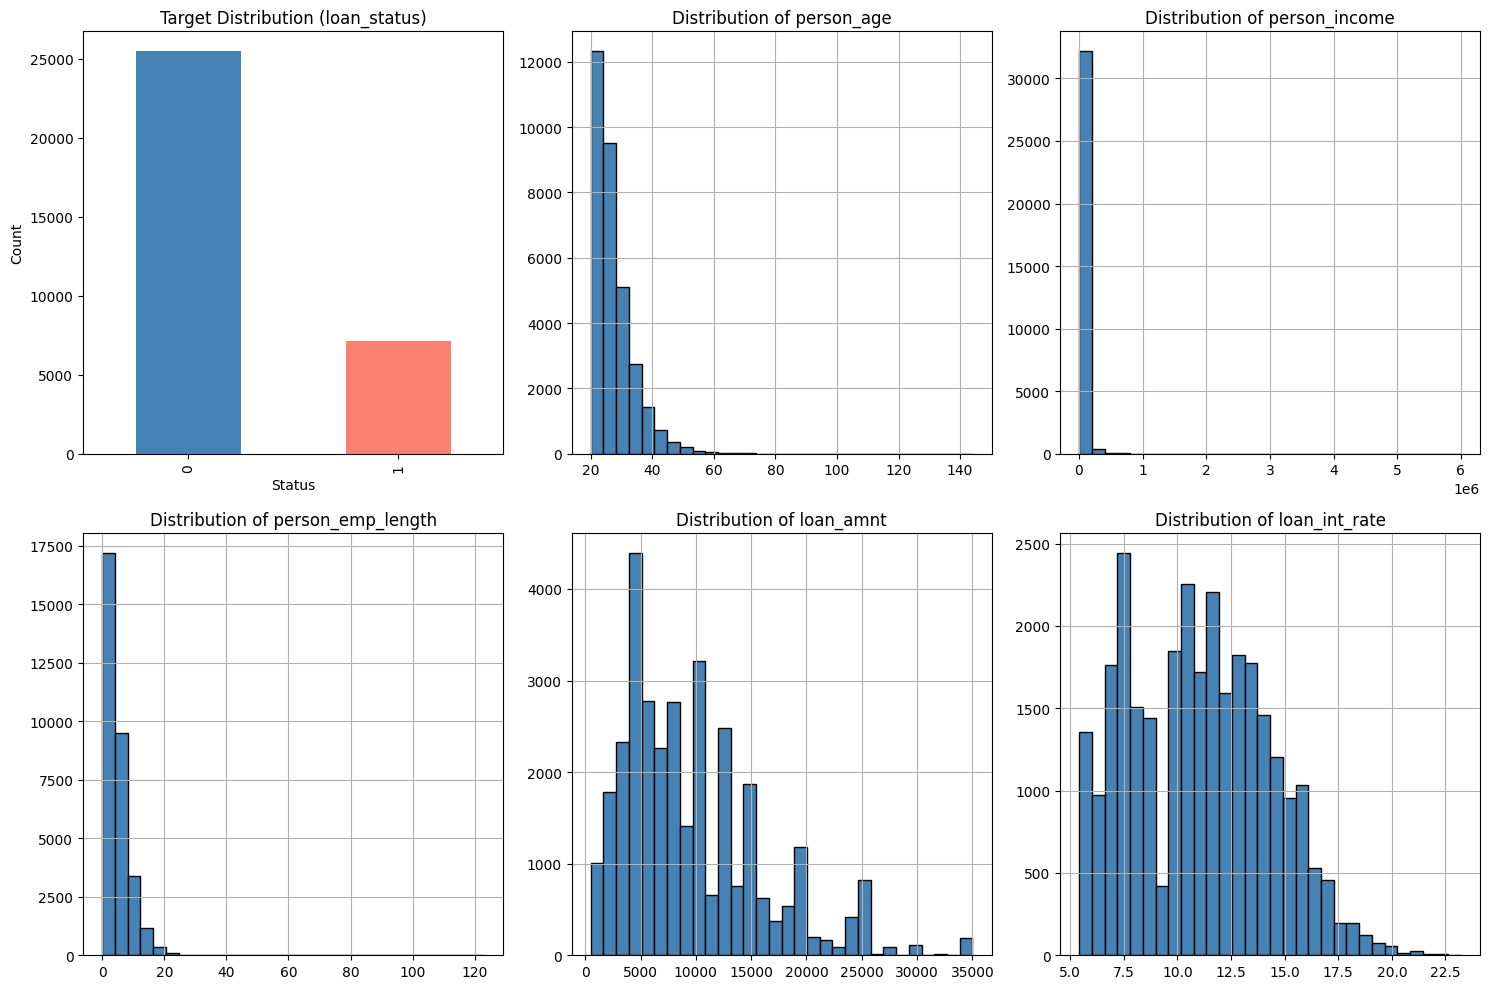

Distribution plot saved!


In [5]:
# Cell 4: EDA - Distribution Analysis
import os
os.makedirs('../preprocessing', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribusi target
df['loan_status'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','salmon'])
axes[0,0].set_title('Target Distribution (loan_status)')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')

# Distribusi 5 fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'loan_status']

for i, col in enumerate(numeric_cols[:5]):
    row, col_idx = divmod(i+1, 3)
    df[col].hist(ax=axes[row, col_idx], bins=30, color='steelblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('eda_distribution.png')
plt.show()
print("Distribution plot saved!")

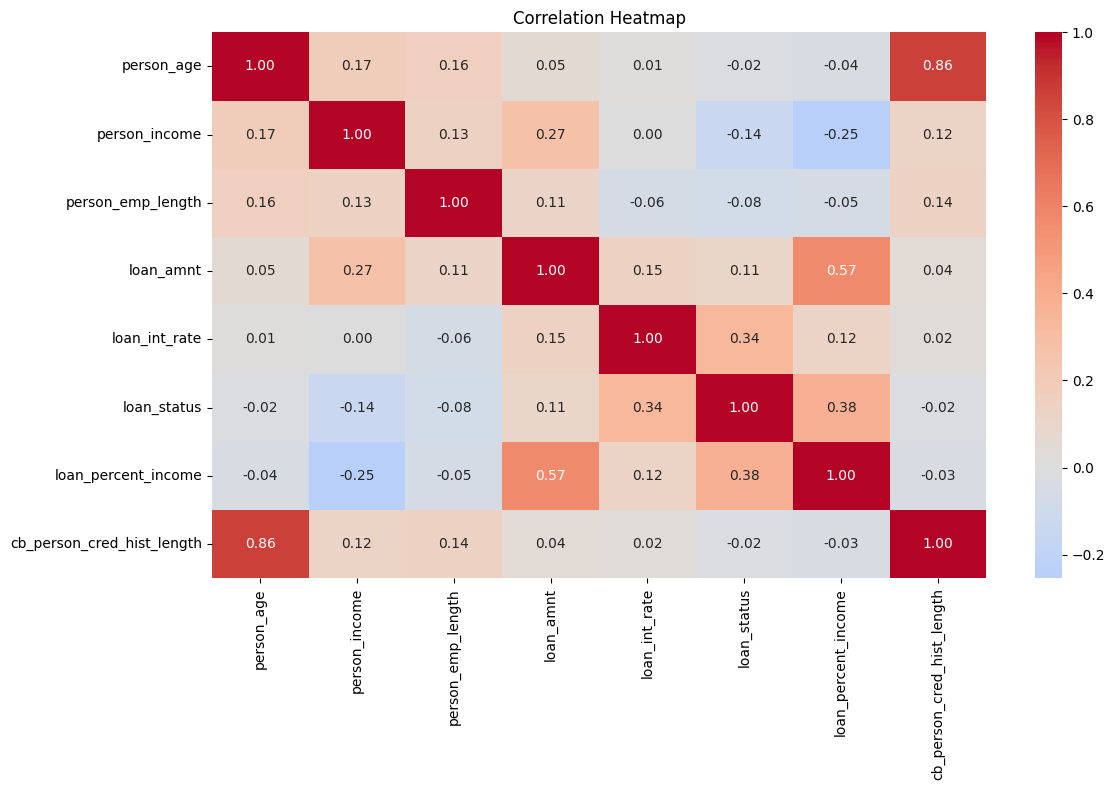

Correlation heatmap saved!


In [6]:
# Cell 5: EDA - Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation.png')
plt.show()
print("Correlation heatmap saved!")

In [7]:
# Cell 6: Preprocessing

# 1. Handle Missing Values
print("=== BEFORE - Missing Values ===")
print(df.isnull().sum())

df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

print("\n=== AFTER - Missing Values ===")
print(df.isnull().sum())

# 2. Remove Duplicates
df.drop_duplicates(inplace=True)
print(f"\nShape after removing duplicates: {df.shape}")

# 3. Handle Outliers (IQR method)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['person_age', 'person_income', 'person_emp_length']:
    df = remove_outliers_iqr(df, col)

print(f"Shape after removing outliers: {df.shape}")

# 4. Encode Categorical Columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"\nCategorical columns encoded: {categorical_cols}")

# 5. Feature Scaling
scaler = StandardScaler()
feature_cols = [c for c in df.columns if c != 'loan_status']
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("\nScaling completed!")
display(df.head())

=== BEFORE - Missing Values ===
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

=== AFTER - Missing Values ===
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Shape after removing duplicates: (32416, 12)
Shape after removing out

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,-1.265562,-1.818902,0.184609,0.185136,-0.878703,-0.194739,-1.382182,0.030009,0,-0.698022,-0.465598,-0.975959
2,-0.355502,-1.818902,-1.216751,-0.996353,0.275467,0.663638,-0.633329,0.567165,1,3.708125,-0.465598,-0.668461
3,-0.810532,0.258048,0.885289,-0.110236,0.275467,0.663638,4.275821,1.299933,1,3.333134,-0.465598,-0.975959
4,-0.583017,-0.154370,0.885289,1.071253,0.275467,0.663638,4.275821,1.001858,1,3.520630,2.147778,-0.360963
5,-1.265562,-1.807755,0.184609,-0.700980,1.429636,-1.053115,-1.132564,-1.211970,1,0.708195,-0.465598,-0.975959


In [8]:
# Cell 7: Train-Test Split & Save
import os

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# Gabungkan kembali untuk disimpan
train_df = X_train.copy()
train_df['loan_status'] = y_train.values

test_df = X_test.copy()
test_df['loan_status'] = y_test.values

os.makedirs('credit_risk_dataset_preprocessing', exist_ok=True)

train_df.to_csv('credit_risk_dataset_preprocessing/train.csv', index=False)
test_df.to_csv('credit_risk_dataset_preprocessing/test.csv', index=False)

print("\nPreprocessed data saved successfully!")
print("Saved to: preprocessing/credit_risk_dataset_preprocessing/")

X_train: (22402, 11)
X_test:  (5601, 11)

Preprocessed data saved successfully!
Saved to: preprocessing/credit_risk_dataset_preprocessing/
